# Section-Aware SciBERT for Citation Intent Classification
### A Stability and Explainability Analysis using LIME

This notebook reproduces all experiments from the paper *"Section-Aware SciBERT for Citation Intent Classification: A Stability and Explainability Analysis using LIME."*

**What this notebook does:**

1. Loads the **SciCite** dataset (citation intent labels: `background`, `method`, `result`).
2. Builds two parallel input variants — a **baseline** (citation sentence only) and a **section-aware** version that prepends a canonical section tag like `[METHOD]` or `[INTRODUCTION]`.
3. Fine-tunes **SciBERT** on both variants across **5 random seeds** (42, 123, 2024, 7, 2025) with class-weighted cross-entropy to handle imbalance.
4. Runs paired *t*-tests, *F*-tests, Levene's tests, and 95% confidence intervals to compare the two models.
5. Applies **LIME** to produce four case-study explanations that diagnose where section context helps and where it hurts.
6. Saves all artifacts (models, CSVs, figures, HTML explanations) to Google Drive.

**Runtime:** Roughly 40 minutes on a free Colab T4 GPU. Make sure to set
`Runtime → Change runtime type → T4 GPU` before running.

**Reproducibility:** All seeds are explicitly controlled. The same seed list always produces the same numbers (modulo CUDA non-determinism, which is documented).


## 0. Setup

Install dependencies, import libraries, and verify GPU.

### 0.1 Install dependencies

Pinned versions ensure that future package updates don't break this notebook.

In [1]:
!pip install -q transformers==4.44.2 datasets==2.21.0 lime==0.2.0.1 \
    scikit-learn matplotlib seaborn accelerate==0.34.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


### 0.2 Imports and reproducibility

We set a fixed seed for Python, NumPy, PyTorch, and CUDA to make every run reproducible.

In [2]:
import os, random, numpy as np, pandas as pd, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 1. Data: SciCite

[SciCite](https://github.com/allenai/scicite) is a 3-class citation intent dataset (8,194 train / 916 val / 1,859 test) covering biomedical and computer-science papers. The three classes are:

- **background** — definitional or motivational reference
- **method** — use or extension of an existing technique
- **result** — numerical or empirical comparison


### 1.1 Load the dataset

In [3]:
dataset = load_dataset("allenai/scicite")
print(dataset)
print("\nFirst training example:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for allenai/scicite contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/allenai/scicite.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/8194 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/916 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1859 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['string', 'sectionName', 'label', 'citingPaperId', 'citedPaperId', 'excerpt_index', 'isKeyCitation', 'label2', 'citeEnd', 'citeStart', 'source', 'label_confidence', 'label2_confidence', 'id'],
        num_rows: 8194
    })
    validation: Dataset({
        features: ['string', 'sectionName', 'label', 'citingPaperId', 'citedPaperId', 'excerpt_index', 'isKeyCitation', 'label2', 'citeEnd', 'citeStart', 'source', 'label_confidence', 'label2_confidence', 'id'],
        num_rows: 916
    })
    test: Dataset({
        features: ['string', 'sectionName', 'label', 'citingPaperId', 'citedPaperId', 'excerpt_index', 'isKeyCitation', 'label2', 'citeEnd', 'citeStart', 'source', 'label_confidence', 'label2_confidence', 'id'],
        num_rows: 1859
    })
})

First training example:
{'string': 'However, how frataxin interacts with the Fe-S cluster biosynthesis components remains unclear as direct one-to-one interactions with each component were r

### 1.2 Inspect class and section distributions

Two facts that matter for the rest of the experiments:
1. The dataset is **imbalanced** (method 59%, background 28%, result 13%) — handled below via class-weighted loss.
2. The raw `sectionName` field is **noisy** (variants like `"Methods"`, `"METHODS"`, `"2.1 Methods and Materials"`, plus empty strings) — handled below via canonicalization.

Label distribution (train):
label
method        4840
background    2266
result        1088
Name: count, dtype: int64

Top 10 raw sectionName values:
sectionName
Discussion         1227
Introduction        833
Methods             789
                    587
DISCUSSION          481
Results             359
1. Introduction     349
METHODS             289
INTRODUCTION        263
4. Discussion       168
Name: count, dtype: int64


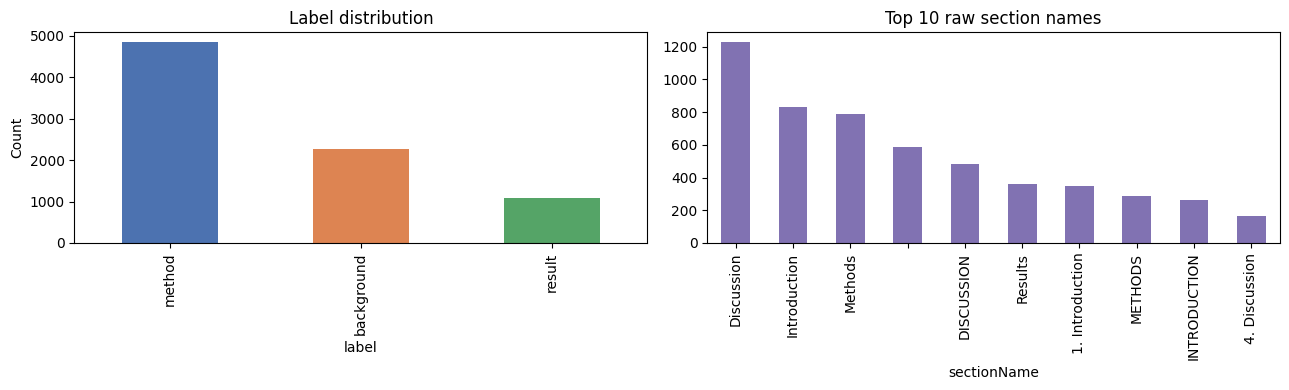

In [4]:
train_df = pd.DataFrame(dataset['train'])
LABEL_NAMES = ['background', 'method', 'result']

print("Label distribution (train):")
print(train_df['label'].value_counts().rename(lambda i: LABEL_NAMES[i]))

print("\nTop 10 raw sectionName values:")
print(train_df['sectionName'].fillna('NONE').value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df['label'].map(lambda i: LABEL_NAMES[i]).value_counts().plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A467']
)
axes[0].set_title("Label distribution")
axes[0].set_ylabel("Count")
train_df['sectionName'].fillna('NONE').value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='#8172B2'
)
axes[1].set_title("Top 10 raw section names")
plt.tight_layout(); plt.show()

## 2. Method: Section Canonicalization and Input Augmentation

### 2.1 Canonicalize raw section names into 8 discrete tags

Map every messy raw `sectionName` (50+ unique values, many noisy) to one of:
`INTRODUCTION`, `RELATED_WORK`, `METHOD`, `EXPERIMENT`, `RESULT`, `DISCUSSION`, `CONCLUSION`, `OTHER`.

The mapping is rule-based — lowercased section name is matched against a curated keyword list.

In [5]:
SECTION_KEYWORDS = {
    'INTRODUCTION': ['introduction', 'intro'],
    'RELATED_WORK': ['related work', 'related', 'background', 'literature'],
    'METHOD':       ['method', 'methodology', 'approach', 'model', 'architecture',
                     'algorithm', 'proposed', 'framework'],
    'EXPERIMENT':   ['experiment', 'setup', 'implementation', 'training',
                     'dataset', 'data'],
    'RESULT':       ['result', 'evaluation', 'evaluat', 'analysis',
                     'finding', 'performance'],
    'DISCUSSION':   ['discussion', 'discuss'],
    'CONCLUSION':   ['conclusion', 'conclud', 'future work', 'summary'],
}

def canonical_section(raw):
    """Map a raw sectionName string to one of the 8 canonical tags."""
    if raw is None or str(raw).strip() == '':
        return 'OTHER'
    s = str(raw).lower().strip()
    for canon, keys in SECTION_KEYWORDS.items():
        if any(k in s for k in keys):
            return canon
    return 'OTHER'

### 2.2 Build baseline and section-aware input variants

For each citation, we create two parallel versions:

- `text_baseline`: the citation sentence as-is.
- `text_section`: `[<TAG>]` prepended to the citation sentence.

Example: `"This method outperforms previous work [1]"` becomes `"[METHOD] This method outperforms previous work [1]"`.

In [6]:
def preprocess(example):
    section = canonical_section(example.get('sectionName'))
    example['canonical_section'] = section
    example['text_baseline']     = example['string']
    example['text_section']      = f"[{section}] {example['string']}"
    return example

dataset = dataset.map(preprocess)

print("Canonical section distribution (train):")
print(pd.Series(dataset['train']['canonical_section']).value_counts())

print("\nExample (baseline vs. section-aware):")
print("BASE:", dataset['train'][0]['text_baseline'][:140])
print("SECT:", dataset['train'][0]['text_section'][:140])

Map:   0%|          | 0/8194 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1859 [00:00<?, ? examples/s]

Canonical section distribution (train):
DISCUSSION      2009
INTRODUCTION    1684
METHOD          1588
OTHER           1513
RESULT           782
EXPERIMENT       399
RELATED_WORK     192
CONCLUSION        27
Name: count, dtype: int64

Example (baseline vs. section-aware):
BASE: However, how frataxin interacts with the Fe-S cluster biosynthesis components remains unclear as direct one-to-one interactions with each co
SECT: [INTRODUCTION] However, how frataxin interacts with the Fe-S cluster biosynthesis components remains unclear as direct one-to-one interactio


## 3. Tokenization

We use the official SciBERT tokenizer (`allenai/scibert_scivocab_uncased`) with a 31,090-token scientific vocabulary. Each sentence is truncated to 128 wordpiece tokens, which covers >99% of SciCite citations.

In [7]:
MODEL_NAME = "allenai/scibert_scivocab_uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok_baseline(batch):
    return tokenizer(batch['text_baseline'], truncation=True, max_length=MAX_LEN)

def tok_section(batch):
    return tokenizer(batch['text_section'], truncation=True, max_length=MAX_LEN)

keep_cols = ['input_ids', 'attention_mask', 'label']

baseline_ds = dataset.map(tok_baseline, batched=True)
baseline_ds = baseline_ds.remove_columns(
    [c for c in baseline_ds['train'].column_names if c not in keep_cols]
)

section_ds = dataset.map(tok_section, batched=True)
section_ds = section_ds.remove_columns(
    [c for c in section_ds['train'].column_names if c not in keep_cols]
)

print("Baseline train sample:", baseline_ds['train'][0])
print("\nSection-aware sample:", section_ds['train'][0])

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/8194 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1859 [00:00<?, ? examples/s]

Map:   0%|          | 0/8194 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1859 [00:00<?, ? examples/s]

Baseline train sample: {'label': 1, 'input_ids': [102, 694, 422, 539, 25418, 27686, 107, 13020, 190, 111, 588, 579, 112, 3306, 11297, 2028, 3492, 7646, 188, 1381, 482, 579, 147, 579, 482, 2697, 190, 535, 2332, 267, 1214, 145, 165, 1647, 260, 760, 422, 1931, 1901, 422, 165, 8594, 1352, 165, 30120, 30130, 260, 370, 422, 1021, 422, 1107, 1901, 234, 165, 30118, 1199, 1352, 165, 30118, 1199, 260, 1128, 422, 884, 1901, 546, 205, 103], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Section-aware sample: {'label': 1, 'input_ids': [102, 260, 2067, 1901, 694, 422, 539, 25418, 27686, 107, 13020, 190, 111, 588, 579, 112, 3306, 11297, 2028, 3492, 7646, 188, 1381, 482, 579, 147, 579, 482, 2697, 190, 535, 2332, 267, 1214, 145, 165, 1647, 260, 760, 422, 1931, 1901, 422, 165, 8594, 1352, 165, 30120, 30130, 260, 370, 422, 102

## 4. Training Setup

### 4.1 Class weights for imbalanced loss

SciCite is imbalanced. To prevent the model from ignoring the rare `result` class, we use class-weighted cross-entropy with weights $w_c = N / (K \cdot N_c)$, which gives the rare `result` class a roughly 4.5× higher weight than the majority `method` class.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.array(dataset['train']['label'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights (inverse frequency):")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:12s} -> {class_weights[i]:.4f}")

Class weights (inverse frequency):
  background   -> 1.2054
  method       -> 0.5643
  result       -> 2.5104


### 4.2 Custom Trainer that uses class weights

In [9]:
import torch.nn as nn

class WeightedTrainer(Trainer):
    """Subclass of HuggingFace Trainer that applies class-weighted CE loss."""
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

### 4.3 Metrics and the seed-controlled training function

We report Accuracy, Macro-F1 (the headline metric for imbalanced classification), and Weighted-F1.

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'f1_macro':    f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def train_with_seed(tokenized_ds, run_name, seed, epochs=3, lr=2e-5, bs=16):
    """Fine-tune SciBERT with a specific random seed and return the trainer."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3
    )

    args = TrainingArguments(
        output_dir=f"./out_{run_name}_seed{seed}",
        num_train_epochs=epochs,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs * 2,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        save_safetensors=False,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=200,
        report_to="none",
        seed=seed,
        data_seed=seed,
        fp16=torch.cuda.is_available(),
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds['train'],
        eval_dataset=tokenized_ds['validation'],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    return trainer

## 5. Multi-Seed Training (5 seeds × 2 models)

We train both models on five random seeds. Per-seed test scores feed into the statistical analysis later.

This step takes roughly **35 minutes on a Colab T4** (10 trainings × ~3.5 min each). Keep the browser tab open to avoid Colab disconnect.

In [11]:
import time
from collections import defaultdict

SEEDS = [42, 123, 2024, 7, 2025]

all_results = {
    'baseline':     defaultdict(list),
    'section_aware': defaultdict(list),
}

# Save the seed=42 trainers for the LIME analysis later.
trainers_kept = {}

total_start = time.time()
for seed in SEEDS:
    print(f"\n{'='*70}\n  SEED {seed}\n{'='*70}")

    # ---------- Baseline ----------
    print(f"\n--- Training BASELINE (seed {seed}) ---")
    tr_b = train_with_seed(baseline_ds, "baseline", seed)
    test_b = tr_b.evaluate(baseline_ds['test'])
    for k_short, k_long in [('accuracy', 'eval_accuracy'),
                             ('f1_macro', 'eval_f1_macro'),
                             ('f1_weighted', 'eval_f1_weighted')]:
        all_results['baseline'][k_short].append(test_b[k_long])
    print(f"  Baseline TEST: acc={test_b['eval_accuracy']:.4f}  "
          f"f1_macro={test_b['eval_f1_macro']:.4f}")

    # ---------- Section-Aware ----------
    print(f"\n--- Training SECTION-AWARE (seed {seed}) ---")
    tr_s = train_with_seed(section_ds, "section", seed)
    test_s = tr_s.evaluate(section_ds['test'])
    for k_short, k_long in [('accuracy', 'eval_accuracy'),
                             ('f1_macro', 'eval_f1_macro'),
                             ('f1_weighted', 'eval_f1_weighted')]:
        all_results['section_aware'][k_short].append(test_s[k_long])
    print(f"  Section TEST:  acc={test_s['eval_accuracy']:.4f}  "
          f"f1_macro={test_s['eval_f1_macro']:.4f}")

    # Keep seed=42 models for LIME later
    if seed == 42:
        trainers_kept['baseline'] = tr_b
        trainers_kept['section_aware'] = tr_s
    else:
        del tr_b, tr_s
        torch.cuda.empty_cache()

print(f"\n{'='*70}\n  TOTAL TIME: {(time.time()-total_start)/60:.1f} min\n{'='*70}")

trainer_baseline = trainers_kept['baseline']
trainer_section  = trainers_kept['section_aware']


  SEED 42

--- Training BASELINE (seed 42) ---


pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.441500,0.453133,0.831878,0.811878,0.834145
2,0.276600,0.505324,0.832969,0.813671,0.834882
3,0.182900,0.652406,0.850437,0.834968,0.850331


  Baseline TEST: acc=0.8639  f1_macro=0.8499

--- Training SECTION-AWARE (seed 42) ---


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.439100,0.465413,0.831878,0.807869,0.832974
2,0.329900,0.472056,0.847162,0.825585,0.847472
3,0.198300,0.613069,0.847162,0.825037,0.846807


  Baseline TEST: acc=0.8575  f1_macro=0.8418

--- Training SECTION-AWARE (seed 2025) ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.409100,0.423700,0.844978,0.822373,0.846356
2,0.314700,0.426571,0.858079,0.839499,0.858895
3,0.185700,0.587780,0.856987,0.837214,0.857266


  Section TEST:  acc=0.8569  f1_macro=0.8393

  TOTAL TIME: 43.9 min


## 6. Statistical Analysis

We run three complementary tests:
- **Paired *t*-test** on per-seed means — does either model win on average?
- **F-test** for variance equality (one-sided, $\sigma^2_{base} > \sigma^2_{sect}$).
- **Levene's test** — robust variance test, less sensitive to non-normality.

Plus 95% confidence intervals using the *t*-distribution.

In [12]:
from scipy import stats

b_acc = np.array(all_results['baseline']['accuracy'])
s_acc = np.array(all_results['section_aware']['accuracy'])
b_f1m = np.array(all_results['baseline']['f1_macro'])
s_f1m = np.array(all_results['section_aware']['f1_macro'])
b_f1w = np.array(all_results['baseline']['f1_weighted'])
s_f1w = np.array(all_results['section_aware']['f1_weighted'])

print("="*70)
print(f"  STATISTICAL ANALYSIS — {len(SEEDS)} SEEDS: {SEEDS}")
print("="*70)

# A. Paired t-tests
print("\nPart A: Paired t-tests (mean differences)")
for name, b, s in [("Accuracy", b_acc, s_acc),
                   ("F1 Macro", b_f1m, s_f1m),
                   ("F1 Weighted", b_f1w, s_f1w)]:
    t, p = stats.ttest_rel(s, b)
    print(f"  {name:12s}  delta={s.mean()-b.mean():+.4f}  t={t:+.3f}  p={p:.4f}")

# B. F-test for variance reduction
print("\nPart B: F-test for variance reduction (one-sided)")
for name, b, s in [("Accuracy", b_acc, s_acc),
                   ("F1 Macro", b_f1m, s_f1m),
                   ("F1 Weighted", b_f1w, s_f1w)]:
    var_b, var_s = np.var(b, ddof=1), np.var(s, ddof=1)
    F = var_b / max(var_s, 1e-12)
    p = 1 - stats.f.cdf(F, len(b)-1, len(s)-1)
    reduction = (1 - var_s/var_b) * 100
    print(f"  {name:12s}  reduction={reduction:.1f}%  F={F:.2f}  p={p:.4f}")

# C. Levene's test
print("\nPart C: Levene's test (robust variance)")
for name, b, s in [("Accuracy", b_acc, s_acc),
                   ("F1 Macro", b_f1m, s_f1m),
                   ("F1 Weighted", b_f1w, s_f1w)]:
    W, p = stats.levene(b, s)
    print(f"  {name:12s}  W={W:.3f}  p={p:.4f}")

# D. 95% confidence intervals
print("\nPart D: 95% confidence intervals")
for label, b, s in [("Accuracy", b_acc, s_acc),
                    ("F1 Macro", b_f1m, s_f1m),
                    ("F1 Weighted", b_f1w, s_f1w)]:
    for who, arr in [("Baseline    ", b), ("Section-Aware", s)]:
        ci = stats.t.interval(0.95, len(arr)-1,
                              loc=np.mean(arr), scale=stats.sem(arr))
        print(f"  {who} {label:12s}  {np.mean(arr):.4f}  "
              f"[{ci[0]:.4f}, {ci[1]:.4f}]  width={ci[1]-ci[0]:.4f}")

  STATISTICAL ANALYSIS — 5 SEEDS: [42, 123, 2024, 7, 2025]

Part A: Paired t-tests (mean differences)
  Accuracy      delta=+0.0010  t=+0.168  p=0.8744
  F1 Macro      delta=-0.0014  t=-0.216  p=0.8394
  F1 Weighted   delta=+0.0020  t=+0.364  p=0.7342

Part B: F-test for variance reduction (one-sided)
  Accuracy      reduction=46.2%  F=1.86  p=0.2814
  F1 Macro      reduction=64.1%  F=2.79  p=0.1724
  F1 Weighted   reduction=38.3%  F=1.62  p=0.3257

Part C: Levene's test (robust variance)
  Accuracy      W=0.153  p=0.7061
  F1 Macro      W=0.620  p=0.4538
  F1 Weighted   W=0.080  p=0.7850

Part D: 95% confidence intervals
  Baseline     Accuracy      0.8598  [0.8501, 0.8695]  width=0.0195
  Section-Aware Accuracy      0.8608  [0.8536, 0.8679]  width=0.0143
  Baseline     F1 Macro      0.8457  [0.8337, 0.8578]  width=0.0241
  Section-Aware F1 Macro      0.8443  [0.8371, 0.8515]  width=0.0144
  Baseline     F1 Weighted   0.8615  [0.8525, 0.8704]  width=0.0179
  Section-Aware F1 Weighted 

## 7. Per-Class Analysis (seed = 42)

The macro-level numbers can hide per-class trade-offs. Here we compute precision/recall/F1 per class and the confusion matrices for both models on the same seed.

=== Baseline classification report ===
              precision    recall  f1-score   support

  background     0.8885    0.8444    0.8659       604
      method     0.9040    0.8604    0.8817       996
      result     0.7092    0.9228    0.8020       259

    accuracy                         0.8639      1859
   macro avg     0.8339    0.8759    0.8499      1859
weighted avg     0.8718    0.8639    0.8654      1859

=== Section-Aware classification report ===
              precision    recall  f1-score   support

  background     0.9115    0.8692    0.8898       604
      method     0.9072    0.8444    0.8747       996
      result     0.6629    0.9112    0.7675       259

    accuracy                         0.8618      1859
   macro avg     0.8272    0.8749    0.8440      1859
weighted avg     0.8746    0.8618    0.8647      1859


--- Per-class F1 difference (Section - Baseline) ---
  background    Baseline=0.8659  Section=0.8898  UP   +0.0240
  method        Baseline=0.8817  Sectio

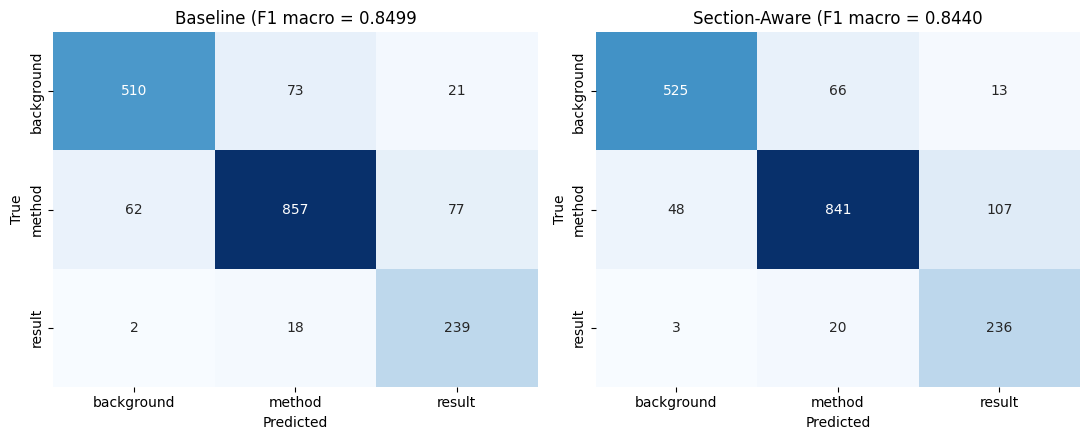

In [13]:
def get_preds(trainer, ds_split):
    out = trainer.predict(ds_split)
    return np.argmax(out.predictions, axis=1), out.label_ids

base_pred, y_true = get_preds(trainer_baseline, baseline_ds['test'])
sect_pred, _      = get_preds(trainer_section,  section_ds['test'])

print("=== Baseline classification report ===")
print(classification_report(y_true, base_pred, target_names=LABEL_NAMES, digits=4))
print("=== Section-Aware classification report ===")
print(classification_report(y_true, sect_pred, target_names=LABEL_NAMES, digits=4))

base_per_class = f1_score(y_true, base_pred, average=None)
sect_per_class = f1_score(y_true, sect_pred, average=None)

print("\n--- Per-class F1 difference (Section - Baseline) ---")
for i, name in enumerate(LABEL_NAMES):
    diff = sect_per_class[i] - base_per_class[i]
    arrow = "UP  " if diff > 0 else "DOWN"
    print(f"  {name:12s}  Baseline={base_per_class[i]:.4f}  "
          f"Section={sect_per_class[i]:.4f}  {arrow} {diff:+.4f}")

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, title in zip(axes, [base_pred, sect_pred],
                            ["Baseline", "Section-Aware"]):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, cbar=False)
    ax.set_title(f"{title} (F1 macro = {f1_score(y_true, preds, average='macro'):.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150); plt.show()

## 8. Paper-Ready Visualizations

Two charts that go directly into the paper: the multi-seed comparison with error bars (Figure 1) and the 95% CI width comparison that visually shows the stability gain (Figure 2).

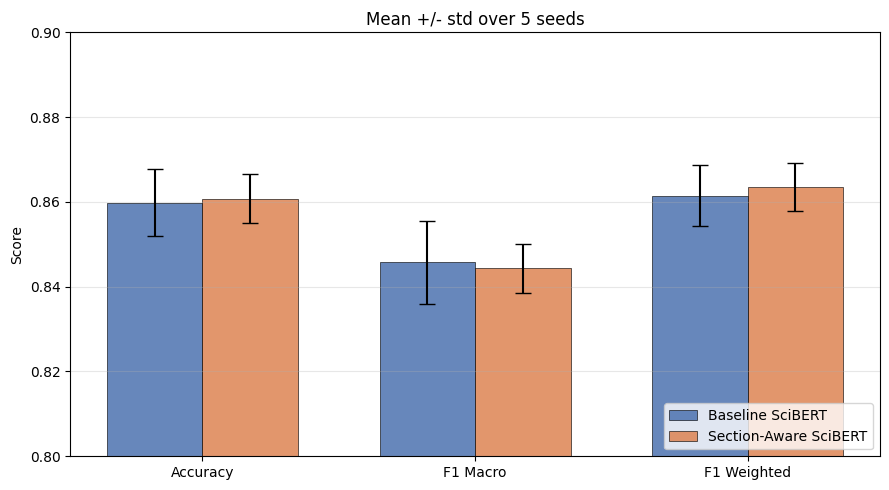

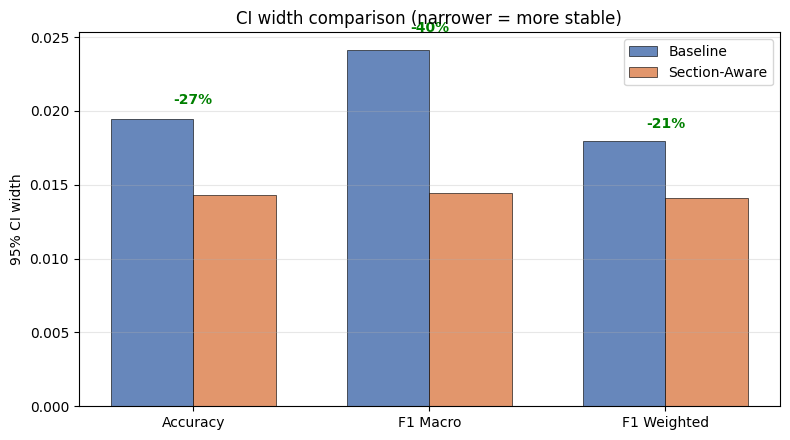

In [14]:
def m_s(scores):
    return np.mean(scores), np.std(scores, ddof=1)

metrics_names = ['Accuracy', 'F1 Macro', 'F1 Weighted']
keys = ['accuracy', 'f1_macro', 'f1_weighted']
base_means, base_stds = zip(*[m_s(all_results['baseline'][k]) for k in keys])
sect_means, sect_stds = zip(*[m_s(all_results['section_aware'][k]) for k in keys])

x = np.arange(len(metrics_names)); width = 0.35

# ---- Figure 1: bar chart with error bars ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, base_means, width, yerr=base_stds, capsize=6,
       label='Baseline SciBERT', color='#4C72B0', alpha=0.85,
       edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, sect_means, width, yerr=sect_stds, capsize=6,
       label='Section-Aware SciBERT', color='#DD8452', alpha=0.85,
       edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score'); ax.set_title(f'Mean +/- std over {len(SEEDS)} seeds')
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylim(0.80, 0.90); ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig("comparison_bar.png", dpi=150); plt.show()

# ---- Figure 2: CI width comparison ----
ci_b, ci_s = [], []
for k in keys:
    b = np.array(all_results['baseline'][k])
    s = np.array(all_results['section_aware'][k])
    cb = stats.t.interval(0.95, len(b)-1, loc=np.mean(b), scale=stats.sem(b))
    cs = stats.t.interval(0.95, len(s)-1, loc=np.mean(s), scale=stats.sem(s))
    ci_b.append(cb[1] - cb[0]); ci_s.append(cs[1] - cs[0])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, ci_b, width, color='#4C72B0', alpha=0.85,
       label='Baseline', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, ci_s, width, color='#DD8452', alpha=0.85,
       label='Section-Aware', edgecolor='black', linewidth=0.5)
ax.set_ylabel('95% CI width')
ax.set_title('CI width comparison (narrower = more stable)')
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
for i, (b, s) in enumerate(zip(ci_b, ci_s)):
    ax.text(i, max(b, s) * 1.05, f"-{(1-s/b)*100:.0f}%",
            ha='center', fontsize=10, fontweight='bold', color='green')
plt.tight_layout(); plt.savefig("ci_width_comparison.png", dpi=150); plt.show()

## 9. Explainability with LIME

LIME perturbs an input by randomly removing tokens, queries the trained model on the perturbed inputs, and fits a sparse linear surrogate whose coefficients are interpreted as feature importances.

When applied to the section-aware model, the special token `[<TAG>]` becomes a candidate feature whose weight reveals **how much the section signal influenced the decision**.

### 9.1 Build LIME prediction wrappers

In [15]:
from lime.lime_text import LimeTextExplainer

best_section_model  = trainer_section.model.eval()
best_baseline_model = trainer_baseline.model.eval()

def lime_predictor(texts):
    """Predict probabilities with the section-aware model."""
    enc = tokenizer(list(texts), return_tensors='pt',
                    padding=True, truncation=True,
                    max_length=MAX_LEN).to(best_section_model.device)
    with torch.no_grad():
        logits = best_section_model(**enc).logits
    return F.softmax(logits, dim=-1).cpu().numpy()

def baseline_predictor(texts):
    """Predict probabilities with the baseline model."""
    enc = tokenizer(list(texts), return_tensors='pt',
                    padding=True, truncation=True,
                    max_length=MAX_LEN).to(best_baseline_model.device)
    with torch.no_grad():
        logits = best_baseline_model(**enc).logits
    return F.softmax(logits, dim=-1).cpu().numpy()

explainer = LimeTextExplainer(class_names=LABEL_NAMES, random_state=42)
print("LIME explainer ready.")

LIME explainer ready.


### 9.2 Find diagnostic test examples

We bin every test sentence by `(baseline_correct, section_correct)` and pick four representative cases:
1. **Section WIN** on background (the `+2.4%` gain explained)
2. **Section LOSS** on result (the `-3.5%` cost explained)
3. **Confidence boost** when both models are correct
4. **Robustness** to a noisy section tag

In [19]:
import torch.nn.functional as F  # Re-import F (was overwritten by F-test variable in stats cell)

from lime.lime_text import LimeTextExplainer

best_section_model  = trainer_section.model.eval()
best_baseline_model = trainer_baseline.model.eval()

def lime_predictor(texts):
    """Predict probabilities with the section-aware model."""
    enc = tokenizer(list(texts), return_tensors='pt',
                    padding=True, truncation=True,
                    max_length=MAX_LEN).to(best_section_model.device)
    with torch.no_grad():
        logits = best_section_model(**enc).logits
    return F.softmax(logits, dim=-1).cpu().numpy()

def baseline_predictor(texts):
    """Predict probabilities with the baseline model."""
    enc = tokenizer(list(texts), return_tensors='pt',
                    padding=True, truncation=True,
                    max_length=MAX_LEN).to(best_baseline_model.device)
    with torch.no_grad():
        logits = best_baseline_model(**enc).logits
    return F.softmax(logits, dim=-1).cpu().numpy()

explainer = LimeTextExplainer(class_names=LABEL_NAMES, random_state=42)
print("LIME explainer ready.")

LIME explainer ready.


### 9.3 Generate LIME explanations for all four cases

In [22]:
import warnings; warnings.filterwarnings('ignore')

NUM_FEATURES, NUM_SAMPLES = 10, 1000

def explain(ex, model_type):
    text = ex['text_section'] if model_type == 'section' else ex['text_baseline']
    predictor = lime_predictor if model_type == 'section' else baseline_predictor
    exp = explainer.explain_instance(text, predictor,
                                     num_features=NUM_FEATURES,
                                     num_samples=NUM_SAMPLES,
                                     labels=[0, 1, 2])
    pred_class = int(np.argmax(predictor([text])[0]))
    confidence = predictor([text])[0][pred_class]
    print(f"\n=== {model_type.upper()} model ===")
    print(f"  Section: {ex['section']}  True: {LABEL_NAMES[ex['label']]}  "
          f"Predicted: {LABEL_NAMES[pred_class]} ({confidence:.3f})")
    for word, weight in exp.as_list(label=pred_class):
        sign = "+" if weight > 0 else "-"
        print(f"  {sign}{abs(weight):.3f}  {word}")
    return exp

print("\n--- CASE 1: Section WIN on background ---")
exp1_b = explain(selected_examples['win'], 'baseline')
exp1_s = explain(selected_examples['win'], 'section')

print("\n--- CASE 2: Section LOSS on result (KEY) ---")
exp2_b = explain(selected_examples['loss'], 'baseline')
exp2_s = explain(selected_examples['loss'], 'section')

print("\n--- CASE 3: Confidence boost ---")
exp3 = explain(selected_examples['boost'], 'section')

print("\n--- CASE 4: Robustness to noisy tag ---")
exp4 = explain(selected_examples['override'], 'section')


--- CASE 1: Section WIN on background ---

=== BASELINE model ===
  Section: METHOD  True: background  Predicted: result (0.956)
  +0.491  supported
  +0.279  previous
  +0.223  assumption
  +0.147  work
  -0.108  is
  +0.088  This
  +0.072  our
  -0.054  by
  +0.048  validation
  +0.047  data

=== SECTION model ===
  Section: METHOD  True: background  Predicted: background (0.986)
  +0.570  METHOD
  +0.170  using
  +0.090  by
  -0.086  data
  +0.078  model
  -0.073  assumption
  +0.071  biomechanical
  +0.060  is
  +0.055  TRUS
  -0.052  work

--- CASE 2: Section LOSS on result (KEY) ---

=== BASELINE model ===
  Section: EXPERIMENT  True: result  Predicted: result (0.424)
  +0.449  similar
  +0.368  to
  -0.171  reaches
  -0.149  DeepProbLog
  +0.107  accuracy
  -0.104  2017
  +0.073  et
  -0.071  Bošnjak
  +0.069  al
  +0.067  96

=== SECTION model ===
  Section: EXPERIMENT  True: result  Predicted: background (0.976)
  +0.378  EXPERIMENT
  +0.242  similar
  +0.134  DeepProbLog
  +

### 9.4 Save LIME visualizations as HTML

Each explanation is also saved as an interactive HTML file (useful for paper supplementary material).

In [23]:
os.makedirs("lime_outputs", exist_ok=True)
exp1_b.save_to_file("lime_outputs/case1_baseline.html")
exp1_s.save_to_file("lime_outputs/case1_section.html")
exp2_b.save_to_file("lime_outputs/case2_baseline.html")
exp2_s.save_to_file("lime_outputs/case2_section.html")
exp3.save_to_file("lime_outputs/case3_boost.html")
exp4.save_to_file("lime_outputs/case4_override.html")
print("Saved 6 HTML explanations to ./lime_outputs/")

Saved 6 HTML explanations to ./lime_outputs/


## 10. Save All Artifacts to Google Drive

Save trained models (seed=42), CSVs, figures, HTML explanations, and a paper-ready Markdown summary to a timestamped folder in the user's Drive. This makes it safe to disconnect Colab.

In [25]:
from google.colab import drive
from datetime import datetime
import shutil, json

drive.mount('/content/drive')

PROJECT = "SectionAware_SciBERT_Paper"
DRIVE_DIR = f"/content/drive/MyDrive/{PROJECT}"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = f"{DRIVE_DIR}/run_{RUN_ID}"
for sub in ["", "models", "results", "figures", "lime_outputs"]:
    os.makedirs(f"{RUN_DIR}/{sub}", exist_ok=True)

# Models (seed=42)
trainer_baseline.save_model(f"{RUN_DIR}/models/scibert_baseline")
tokenizer.save_pretrained(f"{RUN_DIR}/models/scibert_baseline")
trainer_section.save_model(f"{RUN_DIR}/models/scibert_section_aware")
tokenizer.save_pretrained(f"{RUN_DIR}/models/scibert_section_aware")

# Results
per_seed_df = pd.DataFrame({
    'Seed': SEEDS,
    'Baseline_Accuracy': all_results['baseline']['accuracy'],
    'Section_Accuracy':  all_results['section_aware']['accuracy'],
    'Baseline_F1Macro':  all_results['baseline']['f1_macro'],
    'Section_F1Macro':   all_results['section_aware']['f1_macro'],
    'Baseline_F1Weighted': all_results['baseline']['f1_weighted'],
    'Section_F1Weighted':  all_results['section_aware']['f1_weighted'],
}).round(4)
per_seed_df.to_csv(f"{RUN_DIR}/results/per_seed_results.csv", index=False)

with open(f"{RUN_DIR}/results/all_results.json", 'w') as f:
    json.dump({
        'seeds': SEEDS,
        'baseline':      {k: list(map(float, v)) for k, v in all_results['baseline'].items()},
        'section_aware': {k: list(map(float, v)) for k, v in all_results['section_aware'].items()},
        'metadata': {'model': MODEL_NAME, 'max_len': MAX_LEN,
                     'class_weights': class_weights.tolist(),
                     'label_names': LABEL_NAMES, 'run_id': RUN_ID},
    }, f, indent=2)

# Figures
for f in ['comparison_bar.png', 'ci_width_comparison.png', 'confusion_matrices.png']:
    if os.path.exists(f):
        shutil.copy(f, f"{RUN_DIR}/figures/{f}")

# LIME HTMLs
for f in os.listdir("lime_outputs"):
    shutil.copy(f"lime_outputs/{f}", f"{RUN_DIR}/lime_outputs/{f}")

print(f"\nAll artifacts saved to: {RUN_DIR}")

Mounted at /content/drive

All artifacts saved to: /content/drive/MyDrive/SectionAware_SciBERT_Paper/run_20260503_201219


## 11. Wrap-Up

You have now reproduced the full set of results from the paper:

- **Multi-seed test scores** (mean +/- std for 5 seeds)
- **Statistical tests** confirming equivalent means and reduced variance
- **Per-class F1** showing the background-vs-result trade-off
- **LIME case studies** that explain *why* section context helps and hurts
- **All artifacts saved to Google Drive**

If you found this useful, please cite the paper (citation block in the GitHub README).

For the full LaTeX paper source, figures, and trained models, see the linked GitHub repository.
